# Project: Asset Allocation

The file `Data.xlsx` contains historical price data for several assets.

1. Step through the data from Jan2017-Dec2017 and at the end of each month using 1y of trailing data:
    - Recompute/rebalance the weights of each of the following portfolios
        - An equally weighted portfolio
        - An inverse volatility weighted portfolio
        - An equal risk contribution portfolio (use **riskparityportfolio** package)
    - **Note:** each portfolio will be rebalanced 12 times at the end-of-day on the following dates: 2016-12-30 for January, 2017-01-31 for February, 2017-02-28 for March, etc.
1. For each strategy, on each rebalance date, calculate backwards looking estimates of the following:
    - asset risk-contributions
    - portfolio volatilities
1. After completing #1, you now have three portfolios that get reblanced 12 times during 2017.  For this part, for each of the strategies, calculate the follow *realized* performance metrics during 2017:
    - portfolio volatility
    - Sharpe ratio
    - calculate/graph the equity curve
    - max draw-down
    - 99% DVaR
1. Throughout your analysis, write some commentary as to why the numbers you are calculating make sense.

**Grading Rubric:** 
- accuracy of results: 100 pts
- code commenting: 50 pts
- commentary readability of notebook: 50 pts

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
from pandas_datareader import data as pdr
import riskparityportfolio as rp
import matplotlib.pyplot as plt

In [4]:
data = pd.read_excel("Data.xlsx")

### Data cleaning and creating a Dataframe "prices"

In [6]:
## Identifying asset value columns
cols = list(data.columns)
value_cols = [c for c in cols if any(k in str(c) for k in ["Equity", "Index"])]
value_cols

['BCOM Index',
 'DXY Index',
 'GLD Equity',
 'LQD Equity',
 'SPY Equity',
 'TLT Equity']

In [7]:
## For each value column, finding its matching Date column to the LEFT in the same block
pairs = []
for vc in value_cols:
    idx = cols.index(vc)
    date_col = None
    for j in range(idx - 1, -1, -1):
        if "date" in str(cols[j]).lower():
            date_col = cols[j]
            break
    if date_col is not None:
        pairs.append((date_col, vc))

In [8]:
## Building a clean wide DataFrame by aligning each (Date, Asset) pair on the Date index
series_list = []
for dc, vc in pairs:
    tmp = data[[dc, vc]].dropna()
    tmp[dc] = pd.to_datetime(tmp[dc], errors="coerce")
    tmp = tmp.dropna(subset=[dc]).set_index(dc).sort_index()
    tmp = tmp.rename(columns={vc: str(vc)})
    series_list.append(tmp)

prices = pd.concat(series_list, axis=1).sort_index()

In [9]:
## Keeping a neat subset if these are present; otherwise keep whatever is available
preferred = ["SPY Equity", "TLT Equity", "GLD Equity", "LQD Equity", "BCOM Index", "DXY Index"]
present = [c for c in preferred if c in prices.columns]
if present:
    prices = prices[present]
prices

,SPY Equity,TLT Equity,GLD Equity,LQD Equity,BCOM Index,DXY Index
2015-01-01,NaN,NaN,NaN,NaN,NaN,90.276
2015-01-02,205.43,127.32,114.08,119.83,103.8614,91.080
2015-01-05,201.72,129.32,115.80,120.32,103.8730,91.378
2015-01-06,199.82,131.65,117.12,120.81,104.0825,91.499
2015-01-07,202.31,131.39,116.43,120.97,103.5252,91.890
...,...,...,...,...,...,...
2017-12-25,NaN,NaN,NaN,NaN,NaN,93.267
2017-12-26,267.19,125.14,121.77,120.81,86.7311,93.257
2017-12-27,267.32,126.77,122.23,121.48,87.0755,93.025
2017-12-28,267.87,126.66,122.85,121.40,87.6980,92.602


In [10]:
## Aligning to business days, forward-fill missing closes
prices_b = prices.resample("B").last().ffill()

### Returns

In [12]:
## Calculating returns 
rets_all = prices_b.pct_change().dropna()
assets = rets_all.columns.tolist()
N = len(assets)

In [13]:
## Rebalancing dates: Dec-2016 (for Jan-2017) through Nov-2017 (for Dec-2017)
rebalance_dates = pd.date_range("2016-12-01", "2017-11-30", freq="BME")
rebalance_dates = pd.to_datetime([rets_all.index[rets_all.index.get_indexer([d], method="pad")[0]] for d in rebalance_dates])

### Calculating the 1 yr (252 days) trailing covariances for each month and then calculating corresponding weights per strategy

In [15]:
## computing weights with a strict 252-day trailing window
weights_rows = []
LOOKBACK = 252

## T0 be used in risk contribution calc in part-2
sigma_by_date = {}

for d in rebalance_dates:
    loc = rets_all.index.get_indexer([d], method="pad")[0]
    start = loc - LOOKBACK + 1
    if start < 0:
        continue
    win = rets_all.iloc[start:loc+1]
    Sigma = win.cov().values

    sigma_by_date[d] = Sigma  # cache trailing Σ for this rebalance date

    # Equal Weight
    equal_weights = np.ones(N) / N

    # Inverse Volatility
    vols = np.sqrt(np.clip(np.diag(Sigma), a_min=1e-10, a_max=None))
    inverse_volatility = (1 / vols) / np.sum(1 / vols)

    # ERC (risk parity via external lib)
    budget = np.ones(N) / N
    risk_parity = rp.vanilla.design(Sigma, budget)
    risk_parity = np.asarray(risk_parity, dtype=float)
    risk_parity = risk_parity / risk_parity.sum()

    weights_rows += [
        {"date": d, "strategy": "EqualWeight", **{assets[i]: equal_weights[i] for i in range(N)}},
        {"date": d, "strategy": "InvVol",      **{assets[i]: inverse_volatility[i] for i in range(N)}},
        {"date": d, "strategy": "ERC",         **{assets[i]: risk_parity[i] for i in range(N)}},
    ]

### Part - 1 - Each month End weights calculation

In [17]:
weights_df = pd.DataFrame(weights_rows).set_index(["date", "strategy"]).sort_index()
weights_df.head()

SPY Equity  TLT Equity  GLD Equity  LQD Equity  \
date       strategy                                                      
2016-12-30 ERC            0.152170    0.107338    0.104949    0.199555   
           EqualWeight    0.166667    0.166667    0.166667    0.166667   
           InvVol         0.129891    0.126843    0.101192    0.311899   
2017-01-31 ERC            0.162464    0.095200    0.099270    0.192307   
           EqualWeight    0.166667    0.166667    0.166667    0.166667   

                        BCOM Index  DXY Index  
date       strategy                            
2016-12-30 ERC            0.101340   0.334647  
           EqualWeight    0.166667   0.166667  
           InvVol         0.110276   0.219898  
2017-01-31 ERC            0.102614   0.348145  
           EqualWeight    0.166667   0.166667

### Part - 2 Asset Risk Contribution & Portfolio Vols

In [19]:
## calculating portfolio vol
def portfolio_volatility(weights, cov):
    return np.sqrt(np.dot(weights, np.dot(cov, weights.T))) * np.sqrt(252)

In [20]:
## calculating risk contribution
def risk_contributions(weights, cov):
    mctar = np.dot(weights, cov * 252) / portfolio_volatility(weights, cov)
    return mctar * weights / portfolio_volatility(weights, cov)

In [21]:
strategies = ["EqualWeight", "InvVol", "ERC"]
rows_rc, rows_vol = [], []

for d in rebalance_dates:
    Sigma = sigma_by_date.get(d)  # reusing cached Σ

    for strat in strategies:

        w = weights_df.loc[(d, strat), assets].to_numpy(float)

        rc_share = risk_contributions(w, Sigma)            # vector of per-asset shares
        ann_vol  = portfolio_volatility(w, Sigma)          # annualized trailing vol (scalar)

        rows_rc.append({"date": d, "strategy": strat, **{a: rc_share[i] for i, a in enumerate(assets)}})
        rows_vol.append({"date": d, "strategy": strat, "ann_vol_trailing": ann_vol})

#### Risk Contributions

In [23]:
## Final outputs 
risk_contribs = pd.DataFrame(rows_rc).set_index(["date", "strategy"]).sort_index()
risk_contribs.head()

SPY Equity  TLT Equity  GLD Equity  LQD Equity  \
date       strategy                                                      
2016-12-30 ERC            0.166645    0.166687    0.166660    0.166670   
           EqualWeight    0.105564    0.219711    0.334105    0.113740   
           InvVol         0.092897    0.242845    0.201469    0.303592   
2017-01-31 ERC            0.166652    0.166685    0.166658    0.166668   
           EqualWeight    0.075771    0.254972    0.358325    0.122319   

                        BCOM Index  DXY Index  
date       strategy                            
2016-12-30 ERC            0.166670   0.166669  
           EqualWeight    0.272987  -0.046107  
           InvVol         0.162913  -0.003716  
2017-01-31 ERC            0.166668   0.166668  
           EqualWeight    0.260986  -0.072374

#### Portfolio Volatilities

In [25]:
portfolio_vols = pd.DataFrame(rows_vol).set_index(["date", "strategy"]).sort_index()
portfolio_vols.head()

ann_vol_trailing
date       strategy                     
2016-12-30 ERC                  0.037283
           EqualWeight          0.050403
           InvVol               0.041184
2017-01-31 ERC                  0.033285
           EqualWeight          0.048471

### Part - 3: Performance Statistics

In [27]:
## Generating daily portfolio returns using rolling weights
portf_returns = {strategy: [] for strategy in ["EqualWeight", "InvVol", "ERC"]}

for i in range(len(rebalance_dates) - 1):
    start = rebalance_dates[i]
    end = rebalance_dates[i+1]

    ## Fetching weights for the rebalance start date
    for strat in portf_returns.keys():
        if (start, strat) not in weights_df.index:
            continue
        w = weights_df.loc[(start, strat), assets].to_numpy(float)

        ## Slice returns between rebalance dates
        df_window = rets_all.loc[start:end, assets]
        portf_ret = df_window @ w
        portf_ret.name = end
        portf_returns[strat].append(portf_ret)

## Combining into one df
returns_by_strategy = {
    strat: pd.concat(portf_returns[strat]).sort_index()
    for strat in portf_returns
}

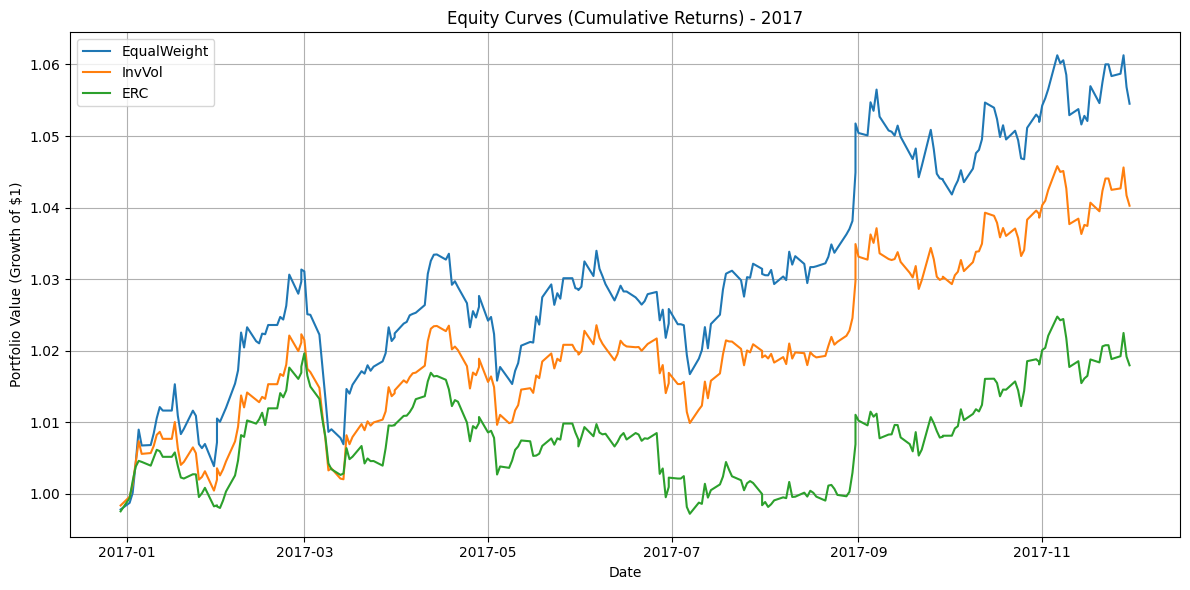

In [28]:
plt.figure(figsize=(12,6))

for strat, r in returns_by_strategy.items():
    cumulative = (1 + r).cumprod()
    plt.plot(cumulative, label=strat)

plt.title("Equity Curves (Cumulative Returns) - 2017")
plt.ylabel("Portfolio Value (Growth of $1)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### The equal weight strategy performed best 

### Computing performance metrics

In [31]:
def compute_performance_metrics(r):
    ## Equity curve
    equity_curve = (1 + r).cumprod()

    ## Annualized Return
    ann_return = (equity_curve.iloc[-1])**(252 / len(r)) - 1

    ## Annualized Volatility
    ann_vol = r.std(ddof=0) * np.sqrt(252)

    ## Sharpe Ratio
    sharpe = (r.mean() / r.std(ddof=0)) * np.sqrt(252)

    ## Max Drawdown
    peak = equity_curve.cummax()
    drawdown = (equity_curve - peak) / peak
    max_dd = drawdown.min()

    ## 99% Daily VaR (non-parametric)
    var_99 = np.percentile(r, 1)  # empirical 1st percentile

    return ann_return, ann_vol, sharpe, max_dd, var_99

In [32]:
## Create DataFrame to store all metrics
summary_rows = []

for strat, r in returns_by_strategy.items():
    ann_ret, vol, sharpe, max_dd, var_99 = compute_performance_metrics(r)
    summary_rows.append({
        "Strategy": strat,
        "Annualized Return": ann_ret,
        "Annualized Volatility": vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd,
        "99% Daily VaR": var_99
    })

In [33]:
df_performance_summary = pd.DataFrame(summary_rows).set_index("Strategy")
display(df_performance_summary)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,99% Daily VaR
Strategy,,,,,
EqualWeight,0.054957,0.035980,1.505088,-0.023669,-0.004976
InvVol,0.040588,0.029788,1.350648,-0.019822,-0.004548
ERC,0.018105,0.025912,0.705454,-0.021987,-0.004156


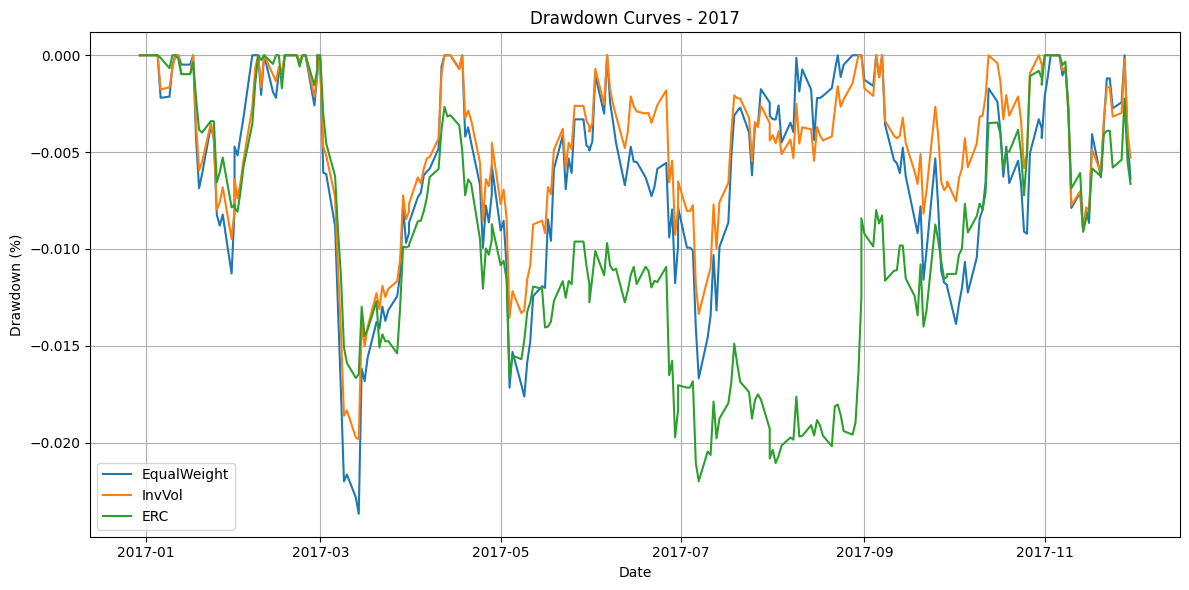

In [34]:
plt.figure(figsize=(12, 6))

for strat, r in returns_by_strategy.items():
    cumulative = (1 + r).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    plt.plot(drawdown, label=strat)

plt.title("Drawdown Curves - 2017")
plt.ylabel("Drawdown (%)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Conclusion:

#### The Equal Weight strategy performed surprisingly well in 2017, offering the highest risk-adjusted returns (Sharpe ratio), even though it was the most volatile of the three. Inverse Volatility was the most balanced, with lower volatility and the smallest drawdowns making it a solid choice for risk-averse investors. The ERC (risk parity) approach was the least volatile, but also had the lowest returns, showing that sometimes, minimizing risk too much can result in geenratign least returns.

#### Looking back, 2017 seems to have been a relatively benign year for risk: broad market indices rose steadily, and there were no major crashes comparable to, say, 2008 or the 2015–2016 periods. Under such ‘steady growth’ conditions, the Equal Weight strategy benefits because it doesn’t under‑allocate to volatile or correlated assets. In contrast, risk‑aware strategies (Inverse Vol, ERC) trade off some upside in order to limit downside but with fewer downside shocks, that cost doesn’t get repaid much. As a result, Equal Weight ends up delivering stronger realized performance in these kinds of calm, bullish markets.